
MODEL PERFORMANCE

Linear Regression
MAE: 73.95
RMSE: 101.55
R2: 0.405
----------------
Random Forest
MAE: 12.36
RMSE: 40.94
R2: 0.903
----------------
Gradient Boosting
MAE: 43.54
RMSE: 62.91
R2: 0.772
----------------
XGBoost
MAE: 30.97
RMSE: 56.14
R2: 0.818
----------------


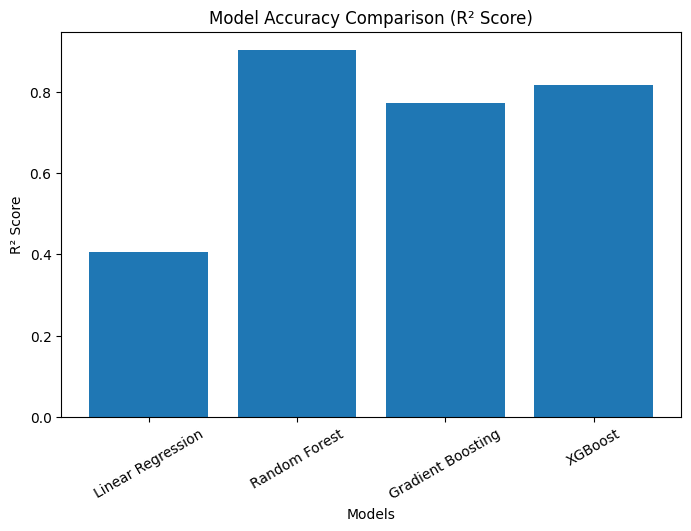

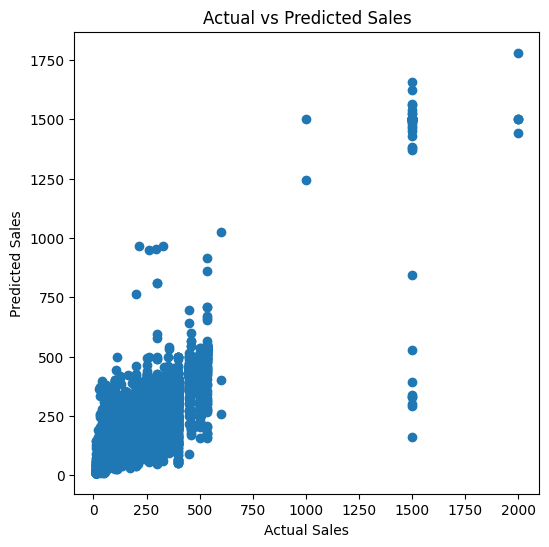

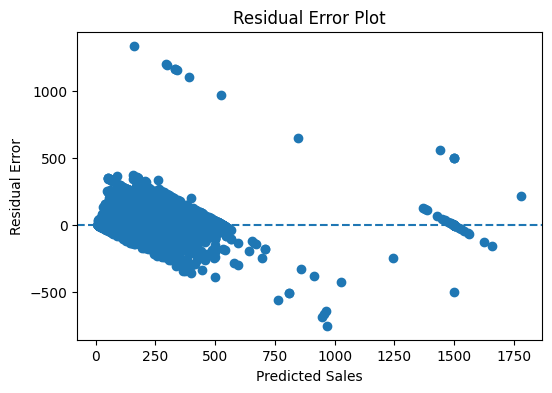

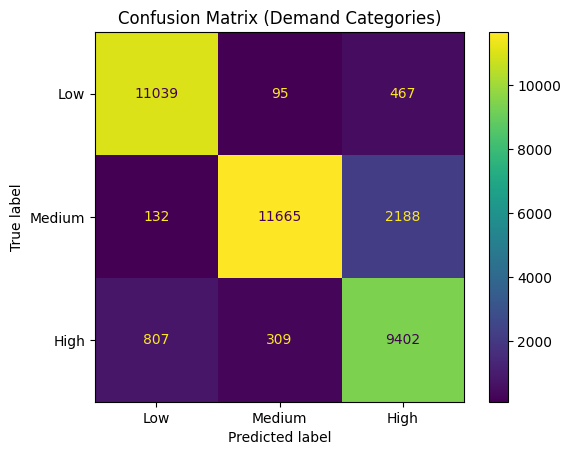


Best Model Saved Successfully
Best R2 Score: 0.9033455772224692


In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor


# ==============================
# 1 Load Dataset
# ==============================

df = pd.read_csv("/content/DataCoSupplyChainDataset.csv", encoding='latin1')

# Select useful columns
df = df[['Sales', 'Order Item Quantity', 'Order Profit Per Order', 'Order Item Discount']]

df = df.dropna()


# ==============================
# 2 Feature / Target Split
# ==============================

X = df.drop(columns=['Sales'])
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ==============================
# 3 Models
# ==============================

models = {

"Linear Regression": LinearRegression(),

"Random Forest": RandomForestRegressor(n_estimators=200),

"Gradient Boosting": GradientBoostingRegressor(),

"XGBoost": XGBRegressor()

}

best_model = None
best_r2 = -999

model_names = []
r2_scores = []

print("\nMODEL PERFORMANCE\n")


# ==============================
# 4 Train Models
# ==============================

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    model_names.append(name)
    r2_scores.append(r2)

    print(name)
    print("MAE:", round(mae, 2))
    print("RMSE:", round(rmse, 2))
    print("R2:", round(r2, 3))
    print("----------------")

    if r2 > best_r2:
        best_r2 = r2
        best_model = model


# ==============================
# 5 Accuracy Graph
# ==============================

plt.figure(figsize=(8,5))
plt.bar(model_names, r2_scores)
plt.title("Model Accuracy Comparison (R² Score)")
plt.xlabel("Models")
plt.ylabel("R² Score")
plt.xticks(rotation=30)
plt.show()


# ==============================
# 6 Best Model Predictions
# ==============================

best_pred = best_model.predict(X_test)


# ==============================
# 7 Actual vs Predicted Plot
# ==============================

plt.figure(figsize=(6,6))
plt.scatter(y_test, best_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()


# ==============================
# 8 Residual Plot
# ==============================

residuals = y_test - best_pred

plt.figure(figsize=(6,4))
plt.scatter(best_pred, residuals)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted Sales")
plt.ylabel("Residual Error")
plt.title("Residual Error Plot")
plt.show()


# ==============================
# 9 Confusion Matrix
# (Convert to categories)
# ==============================

y_test_cat = pd.qcut(y_test, q=3, labels=["Low","Medium","High"])
pred_cat = pd.qcut(best_pred, q=3, labels=["Low","Medium","High"])

cm = confusion_matrix(y_test_cat, pred_cat)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low","Medium","High"]
)

disp.plot()
plt.title("Confusion Matrix (Demand Categories)")
plt.show()


# ==============================
# 10 Save Best Model
# ==============================

os.makedirs('models', exist_ok=True)

joblib.dump(best_model, "models/demand_model.pkl")

print("\nBest Model Saved Successfully")
print("Best R2 Score:", best_r2)